In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import linregress
from scipy.stats import ttest_ind
import funcs
import imp
import random
import mne
from scipy.signal import hilbert
imp.reload(funcs)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from sklearn.linear_model import LinearRegression

C:\Users\Tianyi Zheng\AppData\Local\Temp\ipykernel_8860\913390511.py:13: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


In [3]:
load_path = os.path.join('..', '..', '..', 'data', 'subjects_behavior_excind.pkl')
subjects_behavior_excind = pd.read_pickle(load_path)

load_path = os.path.join('..', '..', '..', 'data', 'subjects_rest_excind.pkl')
subjects_rest_excind = pd.read_pickle(load_path)

In [4]:
exp_info = funcs.load_info()
rpm_answers = funcs.load_rpm_answers()

rpm_difficulty = pd.DataFrame(columns=['question', 'average time', 'difficulty'])
rpm_difficulty['question'] = rpm_answers['question'][0:82]
df = subjects_behavior_excind[(subjects_behavior_excind['reaction time'] != 0) & (subjects_behavior_excind['task time'] == 'pre')]
for i in range(82):
    question_index = rpm_difficulty['question'][i]
    rts = df[df['question'] == question_index]['reaction time']
    rpm_difficulty.loc[i, 'average time'] = rts.mean()
    
conditions = [
    (rpm_difficulty['average time'] < 10),
    (rpm_difficulty['average time'] >= 10) & (rpm_difficulty['average time'] <= 20),
    (rpm_difficulty['average time'] > 20)
]
choices = [1, 2, 3]
rpm_difficulty['difficulty'] = np.select(conditions, choices)

### EASY

In [19]:
easy_questions = rpm_difficulty[rpm_difficulty['difficulty'] == 1]['question']
presham = subjects_behavior_excind[(subjects_behavior_excind['task time'] == 'pre') & (subjects_behavior_excind['condition'] == 'Sham') & (subjects_behavior_excind['question'].isin(easy_questions))][['subject id', 'reaction time', 'R']].dropna()
postsham = subjects_behavior_excind[(subjects_behavior_excind['task time'] == 'post') & (subjects_behavior_excind['condition'] == 'Sham') & (subjects_behavior_excind['question'].isin(easy_questions))][['subject id', 'reaction time', 'R']].dropna()
preactive = subjects_behavior_excind[(subjects_behavior_excind['task time'] == 'pre') & (subjects_behavior_excind['condition'] == 'Active') & (subjects_behavior_excind['question'].isin(easy_questions))][['subject id', 'reaction time', 'R']].dropna()
postactive = subjects_behavior_excind[(subjects_behavior_excind['task time'] == 'post') & (subjects_behavior_excind['condition'] == 'Active') & (subjects_behavior_excind['question'].isin(easy_questions))][['subject id', 'reaction time', 'R']].dropna()

In [20]:
# some preprocessing


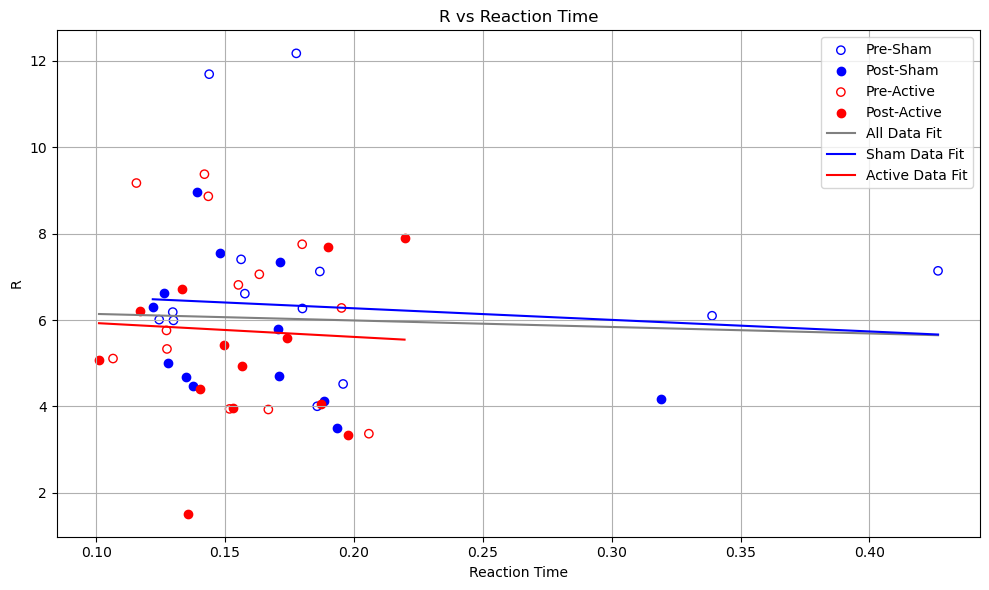

,Fit,R_squared,p_value
0,All Data,0.001758,0.767877
1,Sham Data,0.008468,0.654808
2,Active Data,0.002630,0.803509


In [21]:
# get average values for each subject
avg_presham = presham.groupby('subject id').mean()
avg_postsham = postsham.groupby('subject id').mean()
avg_preactive = preactive.groupby('subject id').mean()
avg_postactive = postactive.groupby('subject id').mean()

# Ensure arrays are NumPy arrays
presham_rt, presham_R = avg_presham['reaction time'].values, avg_presham['R'].values
postsham_rt, postsham_R = avg_postsham['reaction time'].values, avg_postsham['R'].values
preactive_rt, preactive_R = avg_preactive['reaction time'].values, avg_preactive['R'].values
postactive_rt, postactive_R = avg_postactive['reaction time'].values, avg_postactive['R'].values

# Plot data points
plt.figure(figsize=(10, 6))
plt.scatter(presham_R, presham_rt, facecolors='none', edgecolors='blue', label='Pre-Sham')
plt.scatter(postsham_R, postsham_rt, color='blue', label='Post-Sham')
plt.scatter(preactive_R, preactive_rt, facecolors='none', edgecolors='red', label='Pre-Active')
plt.scatter(postactive_R, postactive_rt, color='red', label='Post-Active')

# Combine data for fitting explicitly as numpy arrays
all_rt = np.concatenate([presham_rt, postsham_rt, preactive_rt, postactive_rt])
all_R = np.concatenate([presham_R, postsham_R, preactive_R, postactive_R])

sham_rt = np.concatenate([presham_rt, postsham_rt])
sham_R = np.concatenate([presham_R, postsham_R])

active_rt = np.concatenate([preactive_rt, postactive_rt])
active_R = np.concatenate([preactive_R, postactive_R])

# Fitting function
def fit_and_plot(x, y, color, label):
    slope, intercept, r_value, p_value, _ = linregress(x.astype(float), y)
    x_fit = np.linspace(np.min(x), np.max(x), 100)
    y_fit = intercept + slope * x_fit
    plt.plot(x_fit, y_fit, color=color, label=f'{label} Fit')
    return r_value**2, p_value

# Perform fits
r2_all, p_all = fit_and_plot(all_R, all_rt, 'grey', 'All Data')
r2_sham, p_sham = fit_and_plot(sham_R, sham_rt, 'blue', 'Sham Data')
r2_active, p_active = fit_and_plot(active_R, active_rt, 'red', 'Active Data')

# Plot settings
plt.xlabel('Reaction Time')
plt.ylabel('R')
plt.title('R vs Reaction Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Display fit statistics
fit_stats = pd.DataFrame({
    'Fit': ['All Data', 'Sham Data', 'Active Data'],
    'R_squared': [r2_all, r2_sham, r2_active],
    'p_value': [p_all, p_sham, p_active]
})

fit_stats


In [22]:
pre_sham = funcs.remove_outliers(np.array(presham), low_k=5, high_k=0.1, verbose=True)
post_sham = funcs.remove_outliers(np.array(postsham), low_k=5, high_k=0.5, verbose=True)
pre_active = funcs.remove_outliers(np.array(preactive), low_k=5, high_k=5, verbose=True)
post_active = funcs.remove_outliers(np.array(postactive), low_k=0.5, high_k=10, verbose=True)

means = [np.mean(pre_sham), np.mean(post_sham), np.mean(pre_active), np.mean(post_active)]

multiplier = 1.96*2   # 95% confidence interval
std_errors = [
    multiplier*np.std(pre_sham) / np.sqrt(len(pre_sham)), multiplier*np.std(post_sham) / np.sqrt(len(post_sham)),
    multiplier*np.std(pre_active) / np.sqrt(len(pre_active)), multiplier*np.std(post_active) / np.sqrt(len(post_active))
]

# Calculate t-tests
_, p_sham = stats.ttest_ind(pre_sham, post_sham)
_, p_real = stats.ttest_ind(pre_active, post_active)
_, p_pre = stats.ttest_ind(pre_sham, pre_active)
_, p_post = stats.ttest_ind(post_sham, post_active)

print(f"\nPre-sham vs. Post-sham: p = {p_sham*4}")
print(f"\nPre-active vs. Post-active: p = {p_real*4}")
print(f"\nPre-sham vs. Pre-active: p = {p_pre*4}")
print(f"\nPost-sham vs. Post-active: p = {p_post*4}")

# Bar chart
labels = ['Pre-\nsham', 'Post-\nsham', 'Pre-\nactive', 'Post-\nactive']
colors = ['lightblue', 'blue', 'lightcoral', 'red']

# Plotting
cm = 1/2.54  # centimeters in inches
fig, ax = plt.subplots(figsize=(6*cm, 6*cm))

# Plotting error bars
for i in range(4):
    ax.bar(labels[i], means[i], yerr=std_errors[i], color=colors[i], capsize=5, alpha=0.9)

# Add some additional formatting if desired
ax.set_ylabel('R-value')
# ax.set_title(case)
ax.set_ylim([0.1, 0.2])  # Adjust as needed
# ax.set_yticks([0.5, 1.0, 1.5])
matplotlib.rcParams.update({'font.size': 9})

# Adjust layout and margins
plt.tight_layout(pad=1.0)
# plt.title('Frontal cluster', pad=6)
fig.subplots_adjust(left=0.24, bottom=0.15, right=0.98, top=0.95)
# save_path = os.path.join('..', '..', '..', 'paper', 'excind', 'R_easy.eps')
# plt.savefig(save_path, format='eps')
# save_path = os.path.join('..', '..', '..', 'paper', 'excind', 'R_easy.png')
# plt.savefig(save_path, format='png', dpi=600)
plt.show()

removed -222 outliers out of 174

removed -273 outliers out of 177

removed -348 outliers out of 174

removed -354 outliers out of 177



ValueError: data type <class 'numpy.object_'> not inexact

In [ ]:
# ANOVA
def make_anova_table(pre_sham, post_sham, pre_active, post_active, difficulty):
    df = pd.DataFrame(columns=['condition', 'task_time', 'difficulty', 'reaction_time'])
    # Create a new DataFrame for the new rows to be inserted
    new_rows = pd.DataFrame({
        'condition': ['sham'] * len(pre_sham),    # Repeat 'sham' for the length of rt_sham_before
        'task_time': ['pre'] * len(pre_sham),   # Repeat 'pre' for the same length
        'difficulty': [difficulty] * len(pre_sham),  # Repeat 'endo valid' for the same length
        'reaction_time': pre_sham                        # Reaction times
    })
    df = pd.concat([df, new_rows], ignore_index=True)

    new_rows = pd.DataFrame({
        'condition': ['sham'] * len(post_sham),    # Repeat 'sham' for the length of rt_sham_before
        'task_time': ['post'] * len(post_sham),   # Repeat 'pre' for the same length
        'difficulty': [difficulty] * len(post_sham),  # Repeat 'endo valid' for the same length
        'reaction_time': post_sham                        # Reaction times
    })
    df = pd.concat([df, new_rows], ignore_index=True)

    new_rows = pd.DataFrame({
        'condition': ['active'] * len(pre_active),    # Repeat 'sham' for the length of rt_sham_before
        'task_time': ['pre'] * len(pre_active),   # Repeat 'pre' for the same length
        'difficulty': [difficulty] * len(pre_active),  # Repeat 'endo valid' for the same length
        'reaction_time': pre_active                        # Reaction times
    })
    df = pd.concat([df, new_rows], ignore_index=True)

    new_rows = pd.DataFrame({
        'condition': ['active'] * len(post_active),    # Repeat 'sham' for the length of rt_sham_before
        'task_time': ['post'] * len(post_active),   # Repeat 'pre' for the same length
        'difficulty': [difficulty] * len(post_active),  # Repeat 'endo valid' for the same length
        'reaction_time': post_active                        # Reaction times
    })
    df = pd.concat([df, new_rows], ignore_index=True)

    return df


def fvalue_to_p(fvalue, df_num, df_denom):
    return 1 - stats.f.cdf(fvalue, df_num, df_denom)


anova_table = make_anova_table(pre_sham, post_sham, pre_active, post_active, 'Easy')
# Assuming df is your DataFrame
# Ensure correct data types
# anova_table['reaction_time'] = anova_table['reaction_time'].astype('int')

anova_table['condition'] = anova_table['condition'].astype('category')
anova_table['task_time'] = anova_table['task_time'].astype('category')


# Fit the model
model = ols('reaction_time ~ C(condition) * C(task_time)', data=anova_table).fit()

# Perform ANOVAs
anova_results = anova_lm(model, typ=2)  # Using Type II Sum of Squares

# Calculate Eta Squared
anova_results['eta_sq'] = anova_results['sum_sq'] / sum(anova_results['sum_sq'])
anova_results['p'] = anova_results.apply(lambda row: fvalue_to_p(row['F'], row['df'], 26), axis=1)
anova_results['mod eta_sq'] = anova_results.apply(lambda row: row['eta_sq']*(632/26), axis=1)

anova_results

C:\Users\Tianyi Zheng\AppData\Local\Temp\ipykernel_27240\1309823417.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_rows], ignore_index=True)


,sum_sq,df,F,PR(>F),eta_sq,p,mod eta_sq
C(condition),0.001639,1.0,1.947974,0.163296,0.002999,0.174612,0.072897
C(task_time),0.002409,1.0,2.863580,0.091099,0.004409,0.102558,0.107161
C(condition):C(task_time),0.010721,1.0,12.743147,0.000384,0.019618,0.001420,0.476875
Residual,0.531735,632.0,NaN,NaN,0.972974,NaN,23.650759


### MEDIUM

In [ ]:
def make_R_table(series):
    R_table = []
    for raw in series:
        band = [55, 95] # high gamma band: 55-95 Hz
        eeg = raw.filter(band[0], band[1]).get_data()[1:32,:]
        R = funcs.synchrony_R(eeg)
        R_table.append(R)

    return R_table

difficulty = 2
subset_questions = rpm_difficulty[rpm_difficulty['difficulty'] == difficulty]

matching_rows = subjects_behavior_eeg[subjects_behavior_eeg['question'].isin(subset_questions['question'])]
subset_alpha = matching_rows[matching_rows['correct'] == 1]

pre_sham_series = subset_alpha[(subset_alpha['condition'] == 'Sham') & (subset_alpha['task time'] == 'pre')]['raw']
post_sham_series = subset_alpha[(subset_alpha['condition'] == 'Sham') & (subset_alpha['task time'] == 'post')]['raw']
pre_active_series = subset_alpha[(subset_alpha['condition'] == 'Active') & (subset_alpha['task time'] == 'pre')]['raw']
post_active_series = subset_alpha[(subset_alpha['condition'] == 'Active') & (subset_alpha['task time'] == 'post')]['raw']

presham = make_R_table(pre_sham_series)
postsham = make_R_table(post_sham_series)
preactive = make_R_table(pre_active_series)
postactive = make_R_table(post_active_series)

# 3min 41.2s

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 55 - 95 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 55.00
- Lower transition bandwidth: 13.75 Hz (-6 dB cutoff frequency: 48.12 Hz)
- Upper passband edge: 95.00 Hz
- Upper transition bandwidth: 23.75 Hz (-6 dB cutoff frequency: 106.88 Hz)
- Filter length: 1153 samples (0.240 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 55 - 95 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 55.00
- Lower transition bandwidth: 13.75 Hz (-6 dB cutoff frequency: 48.12 Hz)
- Upper passband edge: 95.00 Hz
- Upper transition bandwidth: 23.75 Hz (-6 dB cutoff frequency: 106.88 Hz)
- Filter length: 1153 samples (0.240 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 55 - 95 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 55.00
- Lower transition bandwidth: 13.75 Hz (-6 dB cutoff frequency: 48.12 Hz)
- Upper passband edge: 95.00 Hz
- Upper transition bandwidth: 23.75 Hz (-6 dB cutoff frequency: 106.88 Hz)
- Filter length: 1153 samples (0.240 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 55 - 95 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 55.00
- Lower transition bandwidth: 13.75 Hz (-6 dB cutoff frequency: 48.12 Hz)
- Upper passba

...

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s



FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 55.00
- Lower transition bandwidth: 13.75 Hz (-6 dB cutoff frequency: 48.12 Hz)
- Upper passband edge: 95.00 Hz
- Upper transition bandwidth: 23.75 Hz (-6 dB cutoff frequency: 106.88 Hz)
- Filter length: 1153 samples (0.240 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 55 - 95 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 55.00
- Lower transition bandwidth: 13.75 Hz (-6 dB cutoff frequency: 48.12 Hz)
- Upper passband edge: 95.00 Hz
- Upper transition bandwidth: 23.75 Hz (-6 dB cutoff frequency: 106.8

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 55 - 95 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 55.00
- Lower transition bandwidth: 13.75 Hz (-6 dB cutoff frequency: 48.12 Hz)
- Upper passband edge: 95.00 Hz
- Upper transition bandwidth: 23.75 Hz (-6 dB cutoff frequency: 106.88 Hz)
- Filter length: 1153 samples (0.240 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


removed 28 outliers out of 173

removed 0 outliers out of 173

removed 0 outliers out of 171

removed 0 outliers out of 172


Pre-sham vs. Post-sham: p = 3.082238154999713

Pre-active vs. Post-active: p = 0.7163364499521736

Pre-sham vs. Pre-active: p = 0.5343221162734093

Post-sham vs. Post-active: p = 2.9726843975528405


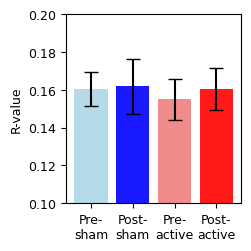

In [ ]:
pre_sham = funcs.remove_outliers(np.array(presham), low_k=5, high_k=0.5, verbose=True)
post_sham = funcs.remove_outliers(np.array(postsham), low_k=5, high_k=5, verbose=True)
pre_active = funcs.remove_outliers(np.array(preactive), low_k=5, high_k=5, verbose=True)
post_active = funcs.remove_outliers(np.array(postactive), low_k=5, high_k=5, verbose=True)

means = [np.mean(pre_sham), np.mean(post_sham), np.mean(pre_active), np.mean(post_active)]

multiplier = 1.96*2   # 95% confidence interval
std_errors = [
    multiplier*np.std(pre_sham) / np.sqrt(len(pre_sham)), multiplier*np.std(post_sham) / np.sqrt(len(post_sham)),
    multiplier*np.std(pre_active) / np.sqrt(len(pre_active)), multiplier*np.std(post_active) / np.sqrt(len(post_active))
]

# Calculate t-tests
_, p_sham = stats.ttest_ind(pre_sham, post_sham)
_, p_real = stats.ttest_ind(pre_active, post_active)
_, p_pre = stats.ttest_ind(pre_sham, pre_active)
_, p_post = stats.ttest_ind(post_sham, post_active)

print(f"\nPre-sham vs. Post-sham: p = {p_sham*4}")
print(f"\nPre-active vs. Post-active: p = {p_real*4}")
print(f"\nPre-sham vs. Pre-active: p = {p_pre*4}")
print(f"\nPost-sham vs. Post-active: p = {p_post*4}")

# Bar chart
labels = ['Pre-\nsham', 'Post-\nsham', 'Pre-\nactive', 'Post-\nactive']
colors = ['lightblue', 'blue', 'lightcoral', 'red']

# Plotting
cm = 1/2.54  # centimeters in inches
fig, ax = plt.subplots(figsize=(6*cm, 6*cm))

# Plotting error bars
for i in range(4):
    ax.bar(labels[i], means[i], yerr=std_errors[i], color=colors[i], capsize=5, alpha=0.9)

# Add some additional formatting if desired
ax.set_ylabel('R-value')
# ax.set_title(case)
ax.set_ylim([0.1, 0.2])  # Adjust as needed
# ax.set_yticks([0.5, 1.0, 1.5])
matplotlib.rcParams.update({'font.size': 9})

# Adjust layout and margins
plt.tight_layout(pad=1.0)
# plt.title('Frontal cluster', pad=6)
fig.subplots_adjust(left=0.24, bottom=0.15, right=0.98, top=0.95)
# save_path = os.path.join('..', '..', '..', 'paper', 'excind', 'R_medium.eps')
# plt.savefig(save_path, format='eps')
# save_path = os.path.join('..', '..', '..', 'paper', 'excind', 'R_medium.png')
# plt.savefig(save_path, format='png', dpi=600)
plt.show()

In [ ]:
# ANOVA
def make_anova_table(pre_sham, post_sham, pre_active, post_active, difficulty):
    df = pd.DataFrame(columns=['condition', 'task_time', 'difficulty', 'reaction_time'])
    # Create a new DataFrame for the new rows to be inserted
    new_rows = pd.DataFrame({
        'condition': ['sham'] * len(pre_sham),    # Repeat 'sham' for the length of rt_sham_before
        'task_time': ['pre'] * len(pre_sham),   # Repeat 'pre' for the same length
        'difficulty': [difficulty] * len(pre_sham),  # Repeat 'endo valid' for the same length
        'reaction_time': pre_sham                        # Reaction times
    })
    df = pd.concat([df, new_rows], ignore_index=True)

    new_rows = pd.DataFrame({
        'condition': ['sham'] * len(post_sham),    # Repeat 'sham' for the length of rt_sham_before
        'task_time': ['post'] * len(post_sham),   # Repeat 'pre' for the same length
        'difficulty': [difficulty] * len(post_sham),  # Repeat 'endo valid' for the same length
        'reaction_time': post_sham                        # Reaction times
    })
    df = pd.concat([df, new_rows], ignore_index=True)

    new_rows = pd.DataFrame({
        'condition': ['active'] * len(pre_active),    # Repeat 'sham' for the length of rt_sham_before
        'task_time': ['pre'] * len(pre_active),   # Repeat 'pre' for the same length
        'difficulty': [difficulty] * len(pre_active),  # Repeat 'endo valid' for the same length
        'reaction_time': pre_active                        # Reaction times
    })
    df = pd.concat([df, new_rows], ignore_index=True)

    new_rows = pd.DataFrame({
        'condition': ['active'] * len(post_active),    # Repeat 'sham' for the length of rt_sham_before
        'task_time': ['post'] * len(post_active),   # Repeat 'pre' for the same length
        'difficulty': [difficulty] * len(post_active),  # Repeat 'endo valid' for the same length
        'reaction_time': post_active                        # Reaction times
    })
    df = pd.concat([df, new_rows], ignore_index=True)

    return df


def fvalue_to_p(fvalue, df_num, df_denom):
    return 1 - stats.f.cdf(fvalue, df_num, df_denom)


anova_table = make_anova_table(pre_sham, post_sham, pre_active, post_active, 'Medium')
# Assuming df is your DataFrame
# Ensure correct data types
# anova_table['reaction_time'] = anova_table['reaction_time'].astype('int')

anova_table['condition'] = anova_table['condition'].astype('category')
anova_table['task_time'] = anova_table['task_time'].astype('category')


# Fit the model
model = ols('reaction_time ~ C(condition) * C(task_time)', data=anova_table).fit()

# Perform ANOVAs
anova_results = anova_lm(model, typ=2)  # Using Type II Sum of Squares

# Calculate Eta Squared
anova_results['eta_sq'] = anova_results['sum_sq'] / sum(anova_results['sum_sq'])
anova_results['p'] = anova_results.apply(lambda row: fvalue_to_p(row['F'], row['df'], 26), axis=1)
anova_results['mod eta_sq'] = anova_results.apply(lambda row: row['eta_sq']*(632/26), axis=1)

anova_results

C:\Users\Tianyi Zheng\AppData\Local\Temp\ipykernel_27240\122221752.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_rows], ignore_index=True)


,sum_sq,df,F,PR(>F),eta_sq,p,mod eta_sq
C(condition),0.001942,1.0,1.310868,0.252655,0.001986,0.262668,0.048275
C(task_time),0.001918,1.0,1.294369,0.255659,0.001961,0.265620,0.047668
C(condition):C(task_time),0.000659,1.0,0.445076,0.504917,0.000674,0.510561,0.016391
Residual,0.973446,657.0,NaN,NaN,0.995379,NaN,24.195358


### HARD

### use all data

In [ ]:
easy_questions = rpm_difficulty[rpm_difficulty['difficulty'] == 3]['question']
presham = subjects_behavior_excind[(subjects_behavior_excind['task time'] == 'pre') & (subjects_behavior_excind['condition'] == 'Sham') & (subjects_behavior_excind['question'].isin(easy_questions))][['subject id', 'reaction time', 'R']].dropna()
postsham = subjects_behavior_excind[(subjects_behavior_excind['task time'] == 'post') & (subjects_behavior_excind['condition'] == 'Sham') & (subjects_behavior_excind['question'].isin(easy_questions))][['subject id', 'reaction time', 'R']].dropna()
preactive = subjects_behavior_excind[(subjects_behavior_excind['task time'] == 'pre') & (subjects_behavior_excind['condition'] == 'Active') & (subjects_behavior_excind['question'].isin(easy_questions))][['subject id', 'reaction time', 'R']].dropna()
postactive = subjects_behavior_excind[(subjects_behavior_excind['task time'] == 'post') & (subjects_behavior_excind['condition'] == 'Active') & (subjects_behavior_excind['question'].isin(easy_questions))][['subject id', 'reaction time', 'R']].dropna()

In [ ]:
# preprocessing
pre_sham = funcs.remove_outliers_df(presham, 'reaction time', low_k=1.5, high_k=1.5, verbose=True)
post_sham = funcs.remove_outliers_df(postsham, 'reaction time', low_k=1.5, high_k=1.5, verbose=True)
pre_active = funcs.remove_outliers_df(preactive, 'reaction time', low_k=1.5, high_k=1.5, verbose=True)
post_active = funcs.remove_outliers_df(postactive, 'reaction time', low_k=1.5, high_k=1.5, verbose=True)

Removed 0 outliers out of 166 rows based on column 'reaction time'.
Removed 0 outliers out of 168 rows based on column 'reaction time'.
Removed 0 outliers out of 156 rows based on column 'reaction time'.
Removed 0 outliers out of 163 rows based on column 'reaction time'.


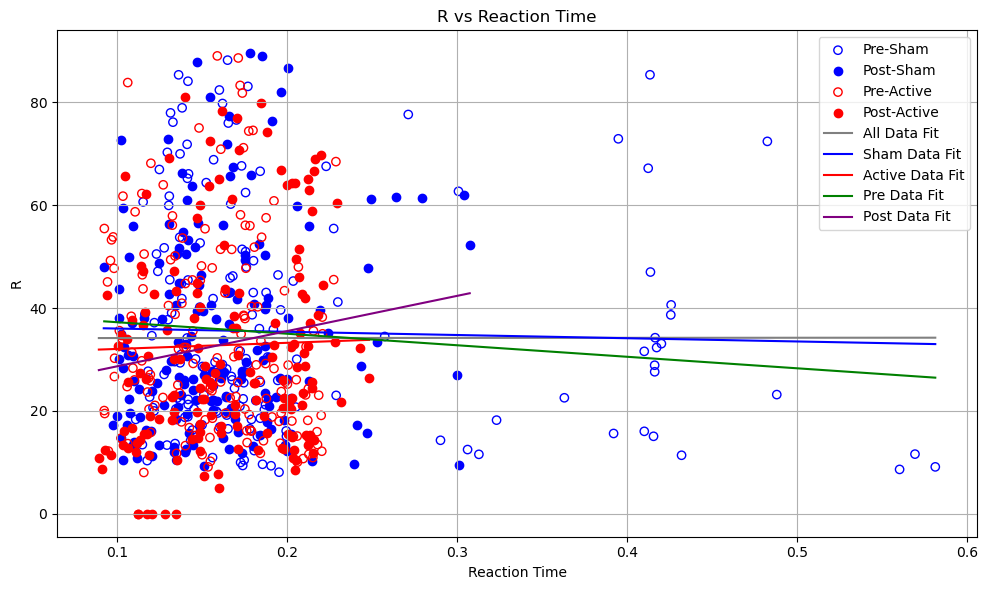

,Fit,R_squared,p_value
0,All Data,2.217416e-07,0.990418
1,Sham Data,6.280382e-04,0.648134
2,Active Data,5.628234e-04,0.672939
3,Pre Data,8.007183e-03,0.109004
4,Post Data,2.167853e-02,0.007291


In [ ]:
# Ensure arrays are NumPy arrays
presham_rt, presham_R = pre_sham['reaction time'].values, pre_sham['R'].values
postsham_rt, postsham_R = post_sham['reaction time'].values, post_sham['R'].values
preactive_rt, preactive_R = pre_active['reaction time'].values, pre_active['R'].values
postactive_rt, postactive_R = post_active['reaction time'].values, post_active['R'].values

# Plot data points
plt.figure(figsize=(10, 6))
plt.scatter(presham_R, presham_rt, facecolors='none', edgecolors='blue', label='Pre-Sham')
plt.scatter(postsham_R, postsham_rt, color='blue', label='Post-Sham')
plt.scatter(preactive_R, preactive_rt, facecolors='none', edgecolors='red', label='Pre-Active')
plt.scatter(postactive_R, postactive_rt, color='red', label='Post-Active')

# Combine data for fitting explicitly as numpy arrays
all_rt = np.concatenate([presham_rt, postsham_rt, preactive_rt, postactive_rt])
all_R = np.concatenate([presham_R, postsham_R, preactive_R, postactive_R])

sham_rt = np.concatenate([presham_rt, postsham_rt])
sham_R = np.concatenate([presham_R, postsham_R])

active_rt = np.concatenate([preactive_rt, postactive_rt])
active_R = np.concatenate([preactive_R, postactive_R])

pre_rt = np.concatenate([presham_rt, preactive_rt])
pre_R = np.concatenate([presham_R, preactive_R])

post_rt = np.concatenate([postsham_rt, postactive_rt])
post_R = np.concatenate([postsham_R, postactive_R])

# Fitting function
def fit_and_plot(x, y, color, label):
    slope, intercept, r_value, p_value, _ = linregress(x.astype(float), y)
    x_fit = np.linspace(np.min(x), np.max(x), 100)
    y_fit = intercept + slope * x_fit
    plt.plot(x_fit, y_fit, color=color, label=f'{label} Fit')
    return r_value**2, p_value

# Perform fits
r2_all, p_all = fit_and_plot(all_R, all_rt, 'grey', 'All Data')
r2_sham, p_sham = fit_and_plot(sham_R, sham_rt, 'blue', 'Sham Data')
r2_active, p_active = fit_and_plot(active_R, active_rt, 'red', 'Active Data')
r2_pre, p_pre = fit_and_plot(pre_R, pre_rt, 'green', 'Pre Data')
r2_post, p_post = fit_and_plot(post_R, post_rt, 'purple', 'Post Data')

# Plot settings
plt.xlabel('Reaction Time')
plt.ylabel('R')
plt.title('R vs Reaction Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Display fit statistics
fit_stats = pd.DataFrame({
    'Fit': ['All Data', 'Sham Data', 'Active Data', 'Pre Data', 'Post Data'],
    'R_squared': [r2_all, r2_sham, r2_active, r2_pre, r2_post],
    'p_value': [p_all, p_sham, p_active, p_pre, p_post]
})

fit_stats


### each subject

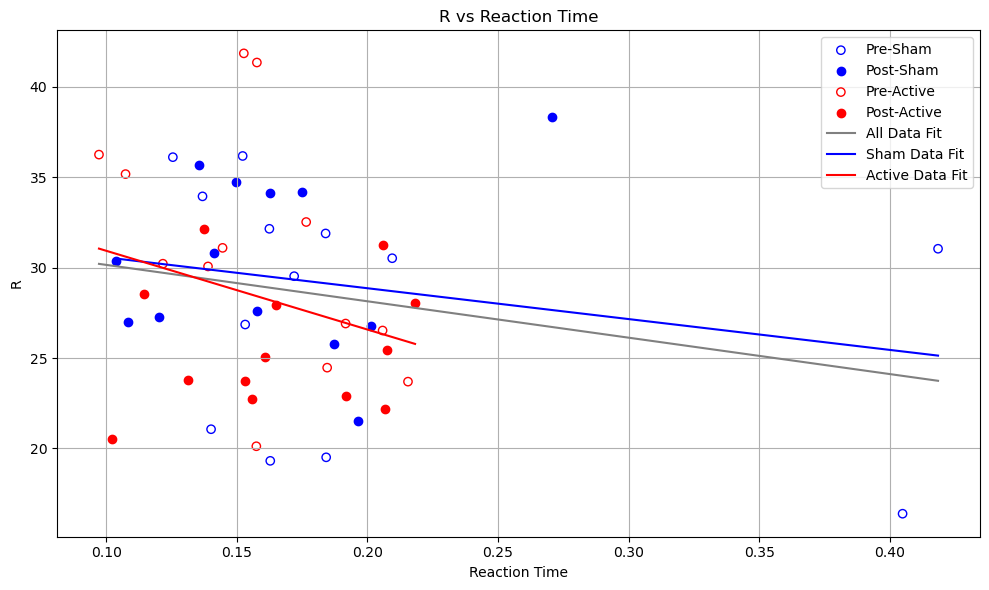

,Fit,R_squared,p_value
0,All Data,0.043402,0.138315
1,Sham Data,0.049053,0.276880
2,Active Data,0.075461,0.174427


In [ ]:
# get average values for each subject
avg_presham = pre_sham.groupby('subject id').mean()
avg_postsham = post_sham.groupby('subject id').mean()
avg_preactive = pre_active.groupby('subject id').mean()
avg_postactive = post_active.groupby('subject id').mean()

# Ensure arrays are NumPy arrays
presham_rt, presham_R = avg_presham['reaction time'].values, avg_presham['R'].values
postsham_rt, postsham_R = avg_postsham['reaction time'].values, avg_postsham['R'].values
preactive_rt, preactive_R = avg_preactive['reaction time'].values, avg_preactive['R'].values
postactive_rt, postactive_R = avg_postactive['reaction time'].values, avg_postactive['R'].values

# Plot data points
plt.figure(figsize=(10, 6))
plt.scatter(presham_R, presham_rt, facecolors='none', edgecolors='blue', label='Pre-Sham')
plt.scatter(postsham_R, postsham_rt, color='blue', label='Post-Sham')
plt.scatter(preactive_R, preactive_rt, facecolors='none', edgecolors='red', label='Pre-Active')
plt.scatter(postactive_R, postactive_rt, color='red', label='Post-Active')

# Combine data for fitting explicitly as numpy arrays
all_rt = np.concatenate([presham_rt, postsham_rt, preactive_rt, postactive_rt])
all_R = np.concatenate([presham_R, postsham_R, preactive_R, postactive_R])

sham_rt = np.concatenate([presham_rt, postsham_rt])
sham_R = np.concatenate([presham_R, postsham_R])

active_rt = np.concatenate([preactive_rt, postactive_rt])
active_R = np.concatenate([preactive_R, postactive_R])

# Fitting function
def fit_and_plot(x, y, color, label):
    slope, intercept, r_value, p_value, _ = linregress(x.astype(float), y)
    x_fit = np.linspace(np.min(x), np.max(x), 100)
    y_fit = intercept + slope * x_fit
    plt.plot(x_fit, y_fit, color=color, label=f'{label} Fit')
    return r_value**2, p_value

# Perform fits
r2_all, p_all = fit_and_plot(all_R, all_rt, 'grey', 'All Data')
r2_sham, p_sham = fit_and_plot(sham_R, sham_rt, 'blue', 'Sham Data')
r2_active, p_active = fit_and_plot(active_R, active_rt, 'red', 'Active Data')

# Plot settings
plt.xlabel('Reaction Time')
plt.ylabel('R')
plt.title('R vs Reaction Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Display fit statistics
fit_stats = pd.DataFrame({
    'Fit': ['All Data', 'Sham Data', 'Active Data'],
    'R_squared': [r2_all, r2_sham, r2_active],
    'p_value': [p_all, p_sham, p_active]
})

fit_stats


### Use each question

In [14]:
hard_questions = rpm_difficulty[rpm_difficulty['difficulty'] == 3]['question']
presham = subjects_behavior_excind[(subjects_behavior_excind['task time'] == 'pre') & (subjects_behavior_excind['condition'] == 'Sham') & (subjects_behavior_excind['question'].isin(hard_questions))][['subject id', 'question', 'reaction time', 'R']].dropna()
postsham = subjects_behavior_excind[(subjects_behavior_excind['task time'] == 'post') & (subjects_behavior_excind['condition'] == 'Sham') & (subjects_behavior_excind['question'].isin(hard_questions))][['subject id', 'question', 'reaction time', 'R']].dropna()
preactive = subjects_behavior_excind[(subjects_behavior_excind['task time'] == 'pre') & (subjects_behavior_excind['condition'] == 'Active') & (subjects_behavior_excind['question'].isin(hard_questions))][['subject id', 'question', 'reaction time', 'R']].dropna()
postactive = subjects_behavior_excind[(subjects_behavior_excind['task time'] == 'post') & (subjects_behavior_excind['condition'] == 'Active') & (subjects_behavior_excind['question'].isin(hard_questions))][['subject id', 'question', 'reaction time', 'R']].dropna()

In [15]:
# For each dataframe, join with subjects_rest_excind on 'subject id' first
presham = presham.merge(subjects_rest_excind[['subject id', 'R pre']], on='subject id', how='left')
postsham = postsham.merge(subjects_rest_excind[['subject id', 'R post']], on='subject id', how='left')
preactive = preactive.merge(subjects_rest_excind[['subject id', 'R pre']], on='subject id', how='left')
postactive = postactive.merge(subjects_rest_excind[['subject id', 'R post']], on='subject id', how='left')

# Perform the division
presham['R_normalized'] = presham['R'] / presham['R pre']
postsham['R_normalized'] = postsham['R'] / postsham['R post']
preactive['R_normalized'] = preactive['R'] / preactive['R pre']
postactive['R_normalized'] = postactive['R'] / postactive['R post']

# (Optional) Drop the joined columns if no longer needed
# presham.drop(columns=['R pre'], inplace=True)
# postsham.drop(columns=['R post'], inplace=True)
# preactive.drop(columns=['R pre'], inplace=True)
# postactive.drop(columns=['R post'], inplace=True)


In [16]:
# preprocessing
pre_sham = funcs.remove_outliers_df(presham, 'reaction time', low_k=1.5, high_k=1.5, verbose=True)
post_sham = funcs.remove_outliers_df(postsham, 'reaction time', low_k=1.5, high_k=1.5, verbose=True)
pre_active = funcs.remove_outliers_df(preactive, 'reaction time', low_k=1.5, high_k=1.5, verbose=True)
post_active = funcs.remove_outliers_df(postactive, 'reaction time', low_k=1.5, high_k=1.5, verbose=True)

Removed 0 outliers out of 166 rows based on column 'reaction time'.
Removed 0 outliers out of 168 rows based on column 'reaction time'.
Removed 0 outliers out of 156 rows based on column 'reaction time'.
Removed 0 outliers out of 163 rows based on column 'reaction time'.


In [17]:
# get average values for each subject
avg_presham = pre_sham.groupby('question').mean()
avg_postsham = post_sham.groupby('question').mean()
avg_preactive = pre_active.groupby('question').mean()
avg_postactive = post_active.groupby('question').mean()

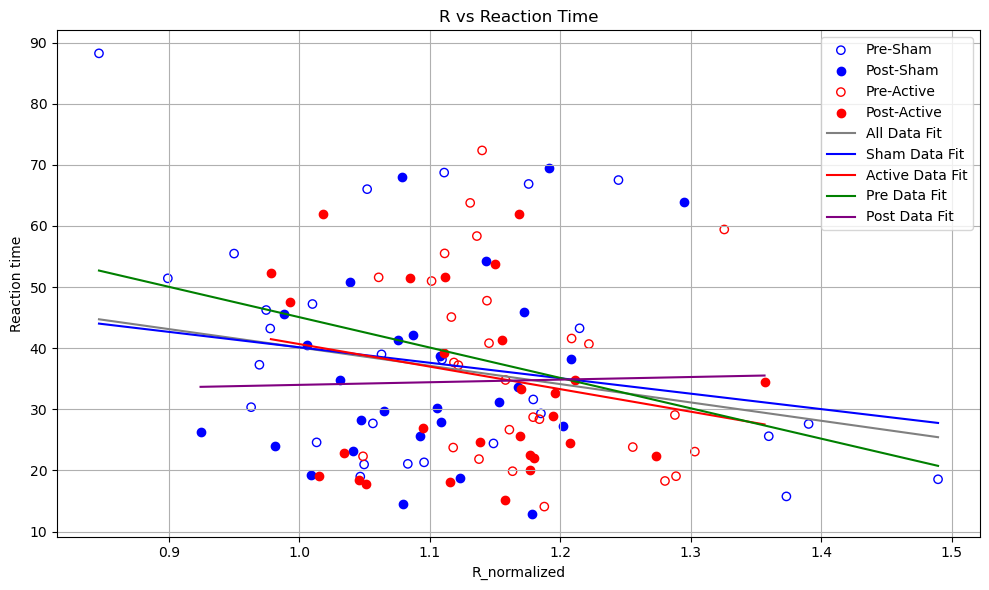

,Fit,R_squared,p_value
0,All Data,-0.200484,0.034049
1,Sham Data,-0.183255,0.176405
2,Active Data,-0.200126,0.139185
3,Pre Data,-0.359274,0.006541
4,Post Data,0.024952,0.855158


In [19]:
# Ensure arrays are NumPy arrays
presham_rt, presham_R = avg_presham['reaction time'].values, avg_presham['R_normalized'].values
postsham_rt, postsham_R = avg_postsham['reaction time'].values, avg_postsham['R_normalized'].values
preactive_rt, preactive_R = avg_preactive['reaction time'].values, avg_preactive['R_normalized'].values
postactive_rt, postactive_R = avg_postactive['reaction time'].values, avg_postactive['R_normalized'].values

# Plot data points
plt.figure(figsize=(10, 6))
plt.scatter(presham_R, presham_rt, facecolors='none', edgecolors='blue', label='Pre-Sham')
plt.scatter(postsham_R, postsham_rt, color='blue', label='Post-Sham')
plt.scatter(preactive_R, preactive_rt, facecolors='none', edgecolors='red', label='Pre-Active')
plt.scatter(postactive_R, postactive_rt, color='red', label='Post-Active')

# Combine data for fitting explicitly as numpy arrays
all_rt = np.concatenate([presham_rt, postsham_rt, preactive_rt, postactive_rt])
all_R = np.concatenate([presham_R, postsham_R, preactive_R, postactive_R])

sham_rt = np.concatenate([presham_rt, postsham_rt])
sham_R = np.concatenate([presham_R, postsham_R])

active_rt = np.concatenate([preactive_rt, postactive_rt])
active_R = np.concatenate([preactive_R, postactive_R])

pre_rt = np.concatenate([presham_rt, preactive_rt])
pre_R = np.concatenate([presham_R, preactive_R])

post_rt = np.concatenate([postsham_rt, postactive_rt])
post_R = np.concatenate([postsham_R, postactive_R])

# Fitting function
def fit_and_plot(x, y, color, label):
    slope, intercept, r_value, p_value, _ = linregress(x.astype(float), y)
    x_fit = np.linspace(np.min(x), np.max(x), 100)
    y_fit = intercept + slope * x_fit
    plt.plot(x_fit, y_fit, color=color, label=f'{label} Fit')
    return r_value, p_value

# Perform fits
r2_all, p_all = fit_and_plot(all_R, all_rt, 'grey', 'All Data')
r2_sham, p_sham = fit_and_plot(sham_R, sham_rt, 'blue', 'Sham Data')
r2_active, p_active = fit_and_plot(active_R, active_rt, 'red', 'Active Data')
r2_pre, p_pre = fit_and_plot(pre_R, pre_rt, 'green', 'Pre Data')
r2_post, p_post = fit_and_plot(post_R, post_rt, 'purple', 'Post Data')

# Plot settings
plt.xlabel('R_normalized')
plt.ylabel('Reaction time')
plt.title('R vs Reaction Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Display fit statistics
fit_stats = pd.DataFrame({
    'Fit': ['All Data', 'Sham Data', 'Active Data', 'Pre Data', 'Post Data'],
    'R_squared': [r2_all, r2_sham, r2_active, r2_pre, r2_post],
    'p_value': [p_all, p_sham, p_active, p_pre, p_post]
})

fit_stats
